In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
fund_master = pd.read_csv("Data/processed/fund_master_clean.csv")

nav_history = pd.read_csv("Data/processed/nav_history_clean.csv")

scheme_performance = pd.read_csv("Data/processed/scheme_performance_clean.csv")

In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
nav_history['date'] = pd.to_datetime(
    nav_history['date']
)

In [7]:
nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

In [8]:
nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [9]:
risk_free_rate = 0.065

sharpe_list = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[nav_history['amfi_code'] == fund]

    avg_return = temp['daily_return'].mean() * 252
    std_return = temp['daily_return'].std() * np.sqrt(252)

    sharpe = (avg_return - risk_free_rate) / std_return

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code', 'sharpe_ratio']
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [10]:
top_sharpe = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

top_sharpe

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


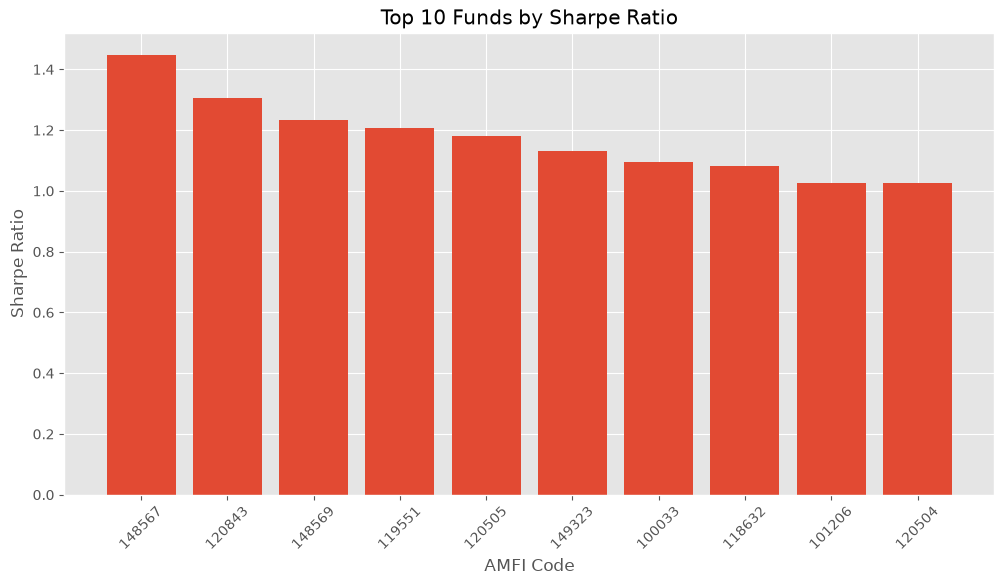

In [11]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sharpe['amfi_code'].astype(str),
    top_sharpe['sharpe_ratio']
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

In [12]:
drawdown_list = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav'] -
        temp['running_max']
    ) / temp['running_max']

    max_dd = temp['drawdown'].min()

    drawdown_list.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [13]:
scorecard = scheme_performance[
    ['amfi_code',
     'scheme_name',
     'return_5yr_pct',
     'expense_ratio_pct']
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on='amfi_code',
    how='left'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code',
    how='left'
)

scorecard.head()

,amfi_code,scheme_name,return_5yr_pct,expense_ratio_pct,sharpe_ratio,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,14.45,1.54,1.208267,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,14.23,0.66,0.953279,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,20.67,1.43,0.945308,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,21.82,0.72,-0.057187,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.43,0.77,-0.226575,-0.043287


In [14]:
scorecard['score'] = (
      scorecard['return_5yr_pct'] * 0.4
    + scorecard['sharpe_ratio'] * 30
    - scorecard['expense_ratio_pct'] * 5
    + scorecard['max_drawdown'] * 20
)

scorecard.head()

,amfi_code,scheme_name,return_5yr_pct,expense_ratio_pct,sharpe_ratio,max_drawdown,score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,14.45,1.54,1.208267,-0.150124,31.325520
1,119552,SBI Bluechip Fund - Direct Plan - Growth,14.23,0.66,0.953279,-0.118035,28.629686
2,119598,SBI Small Cap Fund - Regular Plan - Growth,20.67,1.43,0.945308,-0.287060,23.736047
3,119599,SBI Small Cap Fund - Direct Plan - Growth,21.82,0.72,-0.057187,-0.525742,-7.102443
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.43,0.77,-0.226575,-0.043287,-9.341007


In [15]:
top10 = scorecard.sort_values(
    by='return_5yr_pct',
    ascending=False
).head(10)

top10

,amfi_code,scheme_name,return_5yr_pct,expense_ratio_pct,sharpe_ratio,max_drawdown,score
29,101207,ABSL Small Cap Fund - Regular - Growth,23.80,1.53,0.162661,-0.354469,-0.339560
27,119095,Axis Small Cap Fund - Regular - Growth,22.62,1.38,-0.075974,-0.516778,-10.466758
17,118634,Nippon India Small Cap Fund - Regular - Growth,21.88,1.53,0.448434,-0.233449,9.886043
3,119599,SBI Small Cap Fund - Direct Plan - Growth,21.82,0.72,-0.057187,-0.525742,-7.102443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,20.67,1.43,0.945308,-0.287060,23.736047
39,149324,DSP Small Cap Fund - Regular - Growth,20.61,1.52,0.949796,-0.311719,22.903495
38,149323,DSP Midcap Fund - Regular - Growth,19.00,1.61,1.132122,-0.172481,30.064034
26,119094,Axis Midcap Fund - Regular - Growth,18.94,1.38,0.998231,-0.209609,26.430753
21,120842,Kotak Emerging Equity Fund - Regular - Growth,17.75,1.56,0.076000,-0.240035,-3.220707
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69,1.38,1.093699,-0.162172,29.743521


In [16]:
top10.to_csv(
    "Reports/top10_funds.csv",
    index=False
)

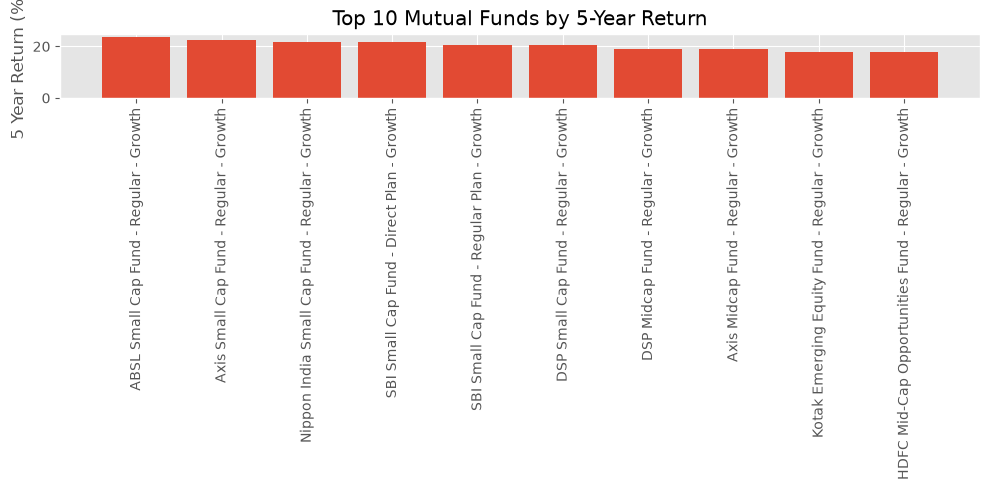

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top10['scheme_name'],
    top10['return_5yr_pct']
)

plt.xticks(rotation=90)
plt.ylabel('5 Year Return (%)')
plt.title('Top 10 Mutual Funds by 5-Year Return')

plt.tight_layout()
plt.show()

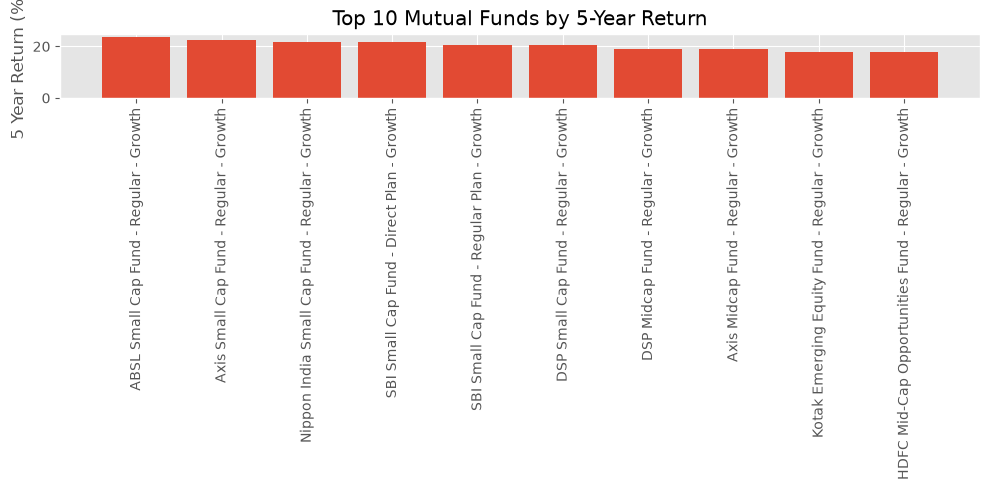

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    top10['scheme_name'],
    top10['return_5yr_pct']
)

plt.xticks(rotation=90)
plt.ylabel('5 Year Return (%)')
plt.title('Top 10 Mutual Funds by 5-Year Return')

plt.tight_layout()

plt.savefig(
    "Reports/top10_funds_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline